# Peramalan kadar $NO_2$ di daerah Makassar

# Latar belakang
Peningkatan aktivitas industri, transportasi, dan pertumbuhan penduduk telah menyebabkan meningkatnya pencemaran udara, salah satunya akibat gas Nitrogen Dioksida (NO₂) yang dihasilkan dari pembakaran bahan bakar fosil. Konsentrasi NO₂ yang tinggi dapat berdampak buruk terhadap kesehatan manusia dan kualitas lingkungan. Oleh karena itu, pemantauan dan prediksi konsentrasi NO₂ menjadi penting untuk mendukung pengelolaan kualitas udara. Dalam penelitian ini, data NO₂ diperoleh dari satelit Sentinel-5P yang menyediakan informasi kualitas udara secara luas dan berkala. Data tersebut kemudian dianalisis menggunakan metode K-Nearest Neighbor (KNN) Regression untuk memprediksi konsentrasi NO₂ di wilayah Makassar berdasarkan data historis selama dua tahun terakhir.

# 1. Pengumpulan Data
Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Bangkalan. Pengumpulan data dari sumber website https://dataspace.copernicus.eu/ , buat akun terlebih dahulu di website copernicus tersebut.

Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html .

Disini kita akan mengambil data kadar NO2 di daerah Makassar

Kita install terlebih dahulu openoneo:


In [4]:
!pip install openeo

In [6]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=OZJW-XCFJ 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Kalian tinggal klik link authentikasi lalu login menggunakan akun “copernicus” kalian.

In [16]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [119.4077105, -5.1134773],
            [119.4447637, -5.1114971],
            [119.4523453, -5.2107162],
            [119.3818470, -5.1930624],
            [119.3879714, -5.1718719],
            [119.3880068, -5.1563388],
            [119.3937722, -5.1506825],
            [119.3927621, -5.1363936],
            [119.4053340, -5.1295129],
            [119.4077105, -5.1134773]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-06-03", "2026-06-03"],
    spatial_extent={
        "west": 119.3818470,
        "south": -5.2107162,
        "east": 119.4523453,
        "north": -5.1114971
    },
    bands=["NO2"],
)

# Agregasi harian
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial pada AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

job = s5post.execute_batch(title="NO2 in Makassar", outputfile="NO2 Makassar.nc")

0:00:00 Job 'j-2606030405194009a83fed0088f6a23b': send 'start'
0:00:24 Job 'j-2606030405194009a83fed0088f6a23b': queued (progress 0%)
0:00:29 Job 'j-2606030405194009a83fed0088f6a23b': queued (progress 0%)
0:00:35 Job 'j-2606030405194009a83fed0088f6a23b': queued (progress 0%)
0:00:43 Job 'j-2606030405194009a83fed0088f6a23b': queued (progress 0%)
0:00:53 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N/A)
0:01:06 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N/A)
0:01:21 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N/A)
0:01:41 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N/A)
0:02:05 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N/A)
0:02:35 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N/A)
0:03:12 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N/A)
0:03:59 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N/A)
0:04:57 Job 'j-2606030405194009a83fed0088f6a23b': running (progress N

Code diatas memerlukan titik koordinasi area yang akan diambil data $NO_2$-nya, untuk mengambil titik koordinasi kaian kunjungi webiste

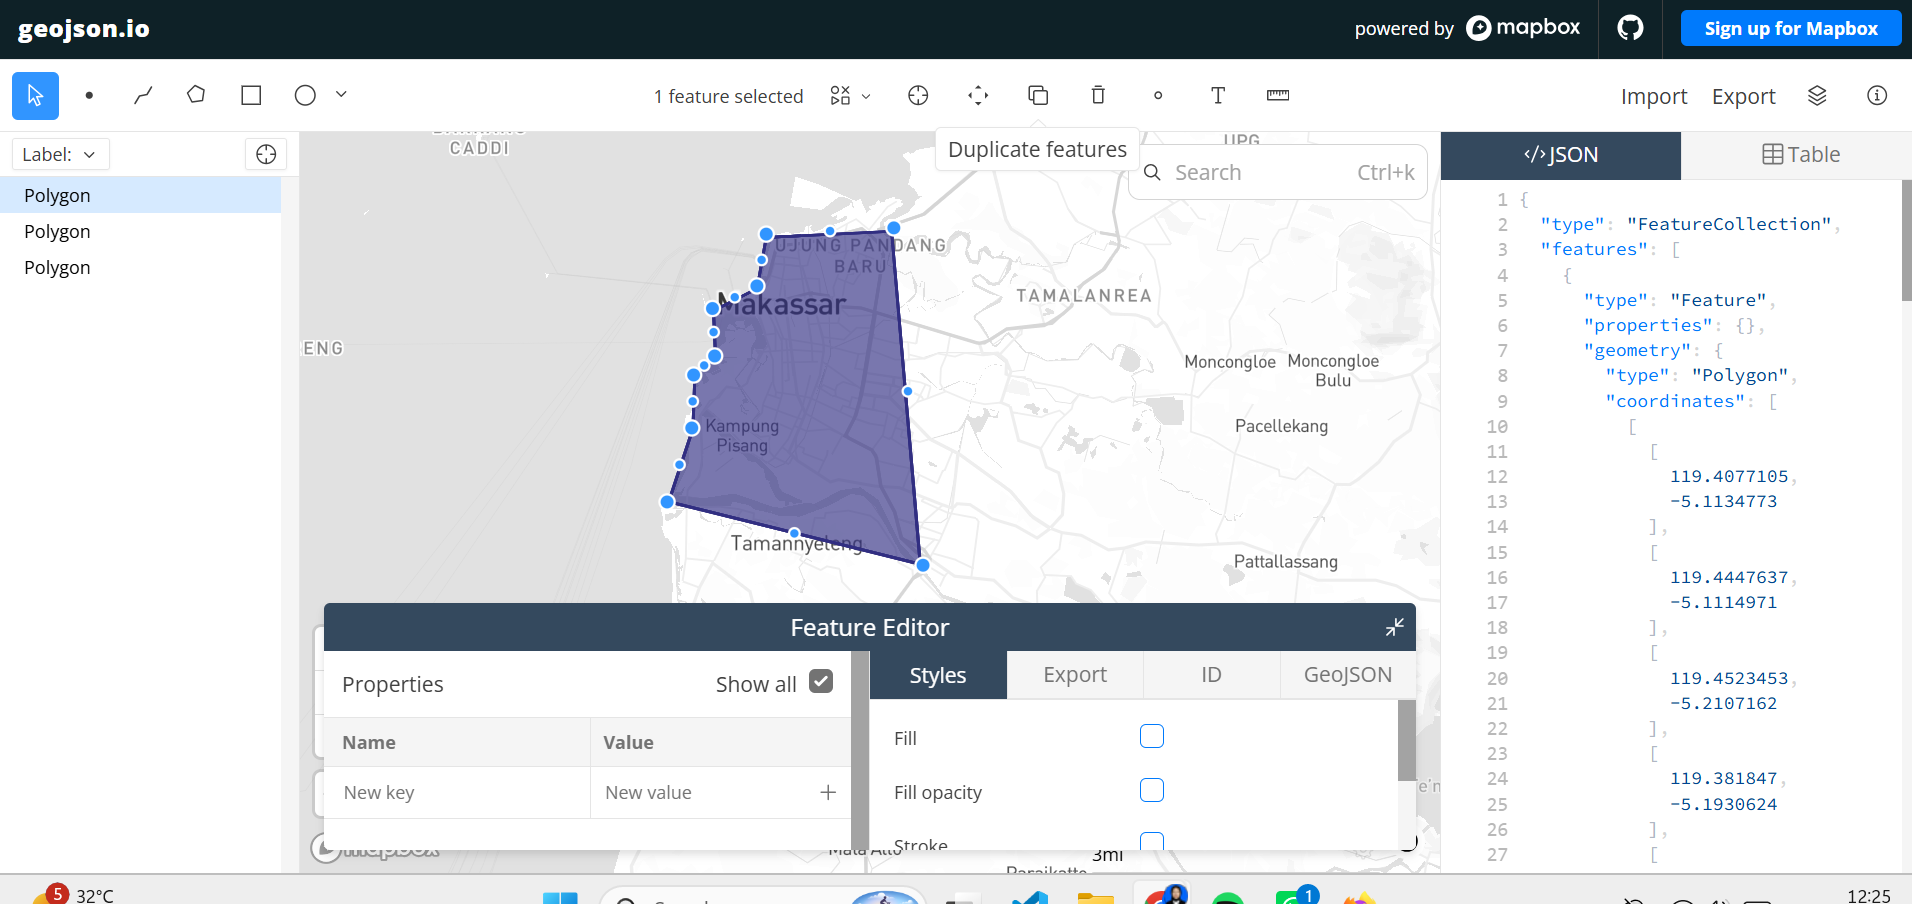

Di panel sebelah kanan terdapat data JSON yang berupa koordinat daerah yang kalian pilih, kalian salin terus sesuaikan dengan code diatas di bagian variabel “aoi” dan spatial_extent.

# 2. Preproccessing Data

Ekstraksi dan Pemeriksaan Data:

Pada tahap ini dilakukan pembacaan data konsentrasi Nitrogen Dioksida (NO₂) yang tersimpan dalam file berformat NetCDF menggunakan library `netCDF4`. File kemudian dibuka dan seluruh variabel yang tersedia ditampilkan untuk mengetahui struktur data yang akan digunakan. Selanjutnya, variabel NO₂ diambil sebagai data utama penelitian, sedangkan variabel waktu (`t`) diekstraksi dan dikonversi ke format tanggal agar dapat digunakan sebagai data deret waktu (time series).

Setelah data berhasil dibaca, dilakukan pemeriksaan struktur data untuk mengetahui tipe data, jumlah record, serta dimensi spasial yang dimiliki. Hasil pemeriksaan menunjukkan bahwa data NO₂ tersimpan dalam bentuk `MaskedArray`, yaitu format array yang dapat menangani nilai yang hilang (missing values). Selain itu, ditampilkan jumlah data pengamatan serta ukuran grid spasial yang merepresentasikan wilayah penelitian. Langkah ini bertujuan untuk memastikan bahwa data telah berhasil dimuat dengan benar dan siap digunakan pada tahap preprocessing serta pemodelan selanjutnya.


In [11]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.2 MB/s eta 0:00:00


In [23]:
import netCDF4

file_path = "NO2 Makassar.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
729
3
2
--


Kode di bawah ini menampilkan Contoh Data NO₂

Tahap ini dilakukan untuk menampilkan beberapa nilai awal dari data konsentrasi NO₂ yang telah diekstraksi. Program menampilkan 10 data pertama menggunakan perulangan (`for`) sehingga pengguna dapat melihat bentuk dan rentang nilai yang tersimpan pada dataset. Langkah ini bertujuan untuk melakukan pemeriksaan awal terhadap data, memastikan bahwa proses ekstraksi berhasil dilakukan dengan benar, serta memberikan gambaran mengenai nilai konsentrasi NO₂ yang akan digunakan pada tahap analisis berikutnya.


In [24]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[-- --]
 [-- --]
 [-- --]]
[[3.422283407417126e-05 --]
 [3.422283407417126e-05 2.320665771549102e-06]
 [3.4576092730276287e-05 2.320665771549102e-06]]
[[-- --]
 [-- --]
 [-- --]]
[[2.5390500013600104e-05 --]
 [1.3072241927147843e-05 1.968077958736103e-05]
 [1.3072241927147843e-05 1.968077958736103e-05]]
[[3.447974086157046e-05 4.5499524276237935e-05]
 [3.447974086157046e-05 4.5499524276237935e-05]
 [3.672980528790504e-05 5.1392242312431335e-05]]
[[3.7140074709896e-05 3.58038887497969e-05]
 [1.4770440429856535e-05 3.220669532311149e-05]
 [1.4770440429856535e-05 2.468380807840731e-05]]
[[-- --]
 [-- --]
 [-- --]]
[[1.0999982805515174e-05 --]
 [1.9538494598236866e-05 --]
 [2.4332834072993137e-05 --]]
[[2.7466792744235136e-05 3.24839202221483e-05]
 [3.218837082386017e-05 2.3736471121083014e-05]
 [1.468702066631522e-05 1.468702066631522e-05]]
[[-- --]
 [-- --]
 [-- --]]


## a. Mengatasi Missing Value menggunakan metode Interpolasi Linear

Dengan code ini, missing value yang terdapat pada data NO2 akan diisi secara otomatis menggunakan metode Interpolasi Linear.

In [25]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

**Keterangan:**

* `np.zeros_like(no2)` digunakan untuk membuat array baru dengan ukuran yang sama seperti data NO₂ asli.
* `filled(0)` digunakan untuk mengganti nilai yang hilang (masked value) menjadi 0 sebagai langkah awal sebelum proses interpolasi.
* Perulangan `for i` dan `for j` digunakan untuk mengakses setiap grid spasial (baris dan kolom) pada data NO₂.
* `pd.Series(no2[:, i, j])` mengubah data NO₂ pada satu titik grid menjadi deret waktu (time series).
* `interpolate(method='linear')` digunakan untuk mengisi nilai yang hilang berdasarkan garis lurus antara nilai sebelum dan sesudahnya.
* `limit_direction='both'` memungkinkan interpolasi dilakukan pada data yang hilang di awal maupun akhir deret waktu.
* Hasil interpolasi disimpan kembali ke dalam variabel `no2_filled`.

Tahap ini bertujuan untuk menghasilkan data yang lengkap tanpa nilai kosong (missing value) sehingga dapat digunakan pada proses analisis dan pemodelan secara lebih optimal.


## b. Rata-rata kan Data dan ubah Datetime

In [26]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

**Keterangan:**

* `new_dates = []` digunakan untuk menyimpan data tanggal yang telah dikonversi ke format yang lebih mudah dibaca.
* `new_no2 = []` digunakan untuk menyimpan nilai rata-rata konsentrasi NO₂ pada setiap waktu pengamatan.
* Perulangan `for i in range(len(dates))` dilakukan untuk memproses seluruh data berdasarkan waktu pengamatan.
* `strftime('%Y-%m-%d')` digunakan untuk mengubah format tanggal menjadi format standar tahun-bulan-hari (YYYY-MM-DD).
* `np.mean(no2_filled[i])` digunakan untuk menghitung nilai rata-rata konsentrasi NO₂ dari seluruh grid spasial pada tanggal tertentu.
* Nilai tanggal dan rata-rata NO₂ kemudian disimpan ke dalam list `new_dates` dan `new_no2`.

Tahap ini bertujuan untuk mengubah data NO₂ yang masih berbentuk grid spasial menjadi data deret waktu (time series) berupa satu nilai rata-rata NO₂ untuk setiap tanggal pengamatan, sehingga lebih mudah digunakan pada proses analisis dan pemodelan selanjutnya.


## c. Simpan data dalam bentuk CSV
Setelah itu kita akan membentuk data menjadi DataFrame Pandas untuk disimpan menjadi CSV.

In [30]:
import numpy as np
import pandas as pd

# Rata-rata seluruh grid untuk setiap waktu
no2_values = np.nanmean(no2, axis=(1, 2))

df = pd.DataFrame({
    "date": dates,
    "NO2": no2_values
})

df.to_csv("NO2_Makassar_timeseries.csv", index=False)

print(df.head())

                  date       NO2
0  2024-06-03 00:00:00       NaN
1  2024-06-04 00:00:00  0.000022
2  2024-06-05 00:00:00       NaN
3  2024-06-06 00:00:00  0.000018
4  2024-06-07 00:00:00  0.000041


**Keterangan:**

* `np.nanmean(no2, axis=(1, 2))` digunakan untuk menghitung rata-rata konsentrasi NO₂ pada seluruh grid spasial untuk setiap waktu pengamatan. Fungsi `nanmean` mengabaikan nilai kosong (`NaN`) sehingga tidak memengaruhi hasil perhitungan.
* `pd.DataFrame()` digunakan untuk membentuk data ke dalam format tabel yang terdiri dari kolom tanggal (`date`) dan nilai rata-rata konsentrasi NO₂ (`NO2`).
* `df.to_csv("NO2_Makassar_timeseries.csv", index=False)` digunakan untuk menyimpan hasil pengolahan data ke dalam file CSV agar dapat digunakan pada tahap analisis berikutnya.
* `print(df.head())` digunakan untuk menampilkan lima data pertama sebagai langkah verifikasi bahwa data telah berhasil dibuat dan disimpan dengan benar.

Tahap ini bertujuan untuk mengubah data NO₂ yang masih berbentuk multidimensi menjadi data deret waktu (time series) berupa rata-rata konsentrasi NO₂ harian di wilayah Makassar, sehingga lebih mudah digunakan dalam proses analisis dan pemodelan prediksi.


## d. Pengecekan Missing Value data harian pada CSV
Sekarang setelah data berbentuk CSV, kita cek apakah data Time Series harian lengkap. Cara men-cek apakah data Time Series Harian lengkap gunakan code dibawah:

In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Makassar_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2024-6-3"
end_date = "2026-6-3"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 2
Daftar tanggal missing:
DatetimeIndex(['2024-08-12', '2026-06-03'], dtype='datetime64[ns]', freq=None)


**Keterangan:**

* `pd.read_csv("NO2_Makassar_timeseries.csv")` digunakan untuk membaca data time series NO₂ yang telah disimpan dalam format CSV.
* `pd.to_datetime(df['date'])` digunakan untuk mengubah kolom tanggal menjadi format datetime agar dapat diproses sebagai data waktu.
* `pd.date_range()` digunakan untuk membuat rentang tanggal harian lengkap dari 3 Juni 2024 hingga 3 Juni 2026.
* `full_range.difference(df['date'])` digunakan untuk membandingkan rentang tanggal lengkap dengan tanggal yang tersedia pada dataset sehingga dapat diketahui tanggal yang hilang (missing date).
* `len(missing_dates)` digunakan untuk menghitung jumlah hari yang tidak memiliki data pengamatan.
* `print(missing_dates)` digunakan untuk menampilkan daftar tanggal yang hilang.

Tahap ini bertujuan untuk mengidentifikasi adanya data yang hilang pada deret waktu (time series). Informasi mengenai tanggal yang hilang diperlukan sebelum proses interpolasi dilakukan agar dataset menjadi lengkap dan dapat digunakan untuk pemodelan secara optimal.


In [46]:
import pandas as pd

# Baca file CSV hasil ekstraksi NO2
df = pd.read_csv("NO2_Makassar_timeseries.csv")

# Lihat nama kolom
print("Kolom yang tersedia:")
print(df.columns.tolist())

# Ambil kolom pertama sebagai tanggal
tanggal_col = df.columns[0]

# Ubah ke datetime
df[tanggal_col] = pd.to_datetime(df[tanggal_col])

# Urutkan berdasarkan tanggal
df = df.sort_values(tanggal_col)

# Rentang tanggal lengkap 2 tahun
full_range = pd.date_range(
    start="2024-06-03",
    end="2026-06-03",
    freq="D"
)

# Reindex
df = df.set_index(tanggal_col).reindex(full_range)
df.index.name = "date"

# Interpolasi data NO2
df["NO2"] = df["NO2"].interpolate(method="time")

# Isi NaN di awal/akhir jika masih ada
df["NO2"] = df["NO2"].bfill().ffill()

# Simpan hasil
df.to_csv("NO2_Makassar_interpolated.csv")

print("\nJumlah data setelah interpolasi:", len(df))
print("\n5 data pertama:")
print(df.head())

print("\nFile berhasil disimpan:")
print("NO2_Makassar_interpolated.csv")

Kolom yang tersedia:
['date', 'NO2']

Jumlah data setelah interpolasi: 731

5 data pertama:
                 NO2
date                
2024-06-03  0.000022
2024-06-04  0.000022
2024-06-05  0.000020
2024-06-06  0.000018
2024-06-07  0.000041

File berhasil disimpan:
NO2_Makassar_interpolated.csv


**Keterangan:**

* `pd.read_csv("NO2_Makassar_timeseries.csv")` digunakan untuk membaca data time series konsentrasi NO₂ yang telah diekstraksi dari file NetCDF.
* `df.columns.tolist()` digunakan untuk menampilkan nama kolom yang tersedia pada dataset sebagai langkah verifikasi struktur data.
* `pd.to_datetime()` digunakan untuk mengubah kolom tanggal menjadi format datetime agar dapat diproses sebagai data deret waktu (time series).
* `sort_values()` digunakan untuk mengurutkan data berdasarkan tanggal secara kronologis.
* `pd.date_range()` digunakan untuk membuat rentang tanggal harian lengkap dari 3 Juni 2024 hingga 3 Juni 2026.
* `set_index()` dan `reindex()` digunakan untuk menyesuaikan dataset dengan rentang tanggal lengkap sehingga tanggal yang tidak memiliki data akan muncul sebagai nilai kosong (NaN).
* `interpolate(method="time")` digunakan untuk mengisi data yang hilang menggunakan metode interpolasi berdasarkan waktu sehingga pola data tetap terjaga.
* `bfill()` dan `ffill()` digunakan untuk mengisi nilai kosong yang masih tersisa pada bagian awal atau akhir deret waktu.
* `to_csv()` digunakan untuk menyimpan hasil interpolasi ke dalam file baru bernama `NO2_Makassar_interpolated.csv`.
* `print()` digunakan untuk menampilkan jumlah data setelah interpolasi, lima data pertama, serta informasi penyimpanan file sebagai proses verifikasi.

Tahap ini bertujuan untuk menghasilkan data deret waktu NO₂ yang lengkap tanpa adanya tanggal yang hilang. Dengan melakukan interpolasi, data menjadi lebih siap digunakan pada tahap analisis lanjutan dan pemodelan prediksi menggunakan algoritma K-Nearest Neighbor (KNN) Regression.


## e. Deteksi Outlier IQR
Setelah kita mengisi missing value menggunakan metode Interpolasi Linear, selanjutnya kita akan mendeteksi Outlier menggunakan metode IQR.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 10
          date       NO2
23  2024-06-26  0.000073
421 2025-07-29  0.000045
423 2025-07-31  0.000057
427 2025-08-04  0.000047
437 2025-08-14  0.000044


**Keterangan:**

* `pd.read_csv("no2_timeseries_interpolated.csv")` digunakan untuk membaca data NO₂ yang telah melalui proses interpolasi.
* `pd.to_datetime(df['date'])` digunakan untuk mengubah kolom tanggal menjadi format datetime agar dapat diproses sebagai data deret waktu.
* `quantile(0.25)` dan `quantile(0.75)` digunakan untuk menghitung kuartil pertama (Q1) dan kuartil ketiga (Q3) dari data NO₂.
* `IQR = Q3 - Q1` digunakan untuk menghitung nilai Interquartile Range (IQR), yaitu rentang antara kuartil ketiga dan kuartil pertama.
* `lower_bound` dan `upper_bound` digunakan untuk menentukan batas bawah dan batas atas data normal berdasarkan metode IQR.
* Data yang memiliki nilai NO₂ di bawah batas bawah atau di atas batas atas akan dikategorikan sebagai outlier.
* `outliers_iqr` digunakan untuk menyimpan data yang teridentifikasi sebagai outlier.
* `print()` digunakan untuk menampilkan jumlah outlier yang ditemukan serta beberapa data outlier pertama sebagai hasil verifikasi.

Tahap ini bertujuan untuk mendeteksi nilai-nilai anomali (outlier) pada data konsentrasi NO₂. Identifikasi outlier penting dilakukan karena nilai yang terlalu jauh dari pola umum data dapat memengaruhi hasil analisis dan performa model prediksi yang akan dibangun.


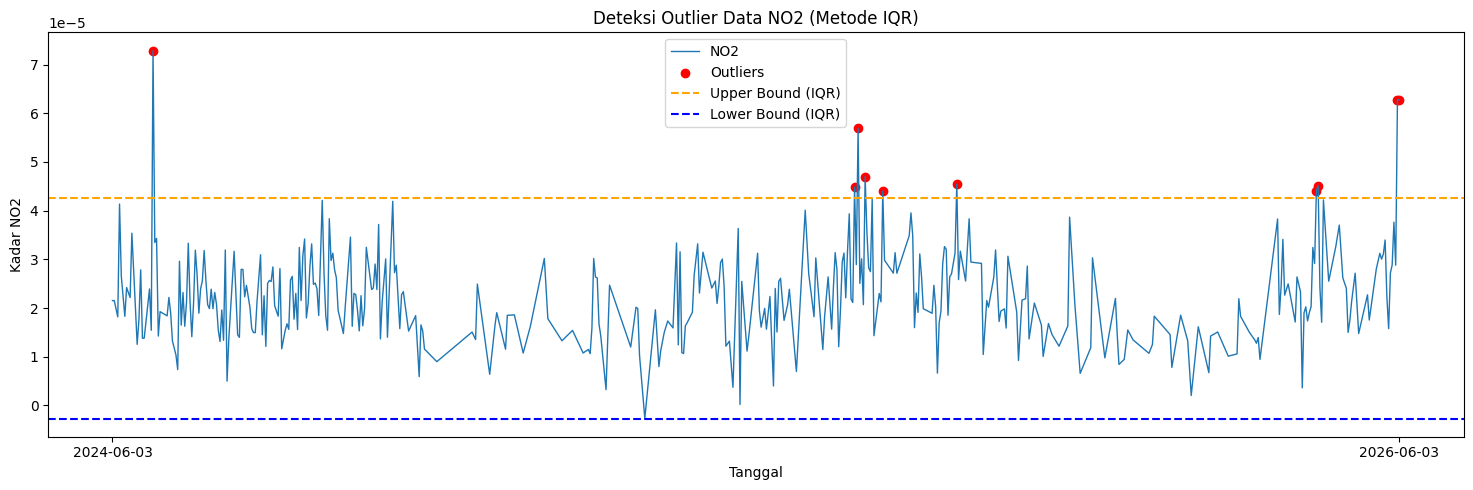

In [49]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

**Keterangan:**

* `plt.figure(figsize=(15,5))` digunakan untuk membuat area grafik dengan ukuran 15 × 5 inci agar visualisasi lebih jelas.
* `plt.plot()` digunakan untuk menampilkan grafik deret waktu (time series) konsentrasi NO₂ berdasarkan tanggal pengamatan.
* `plt.scatter()` digunakan untuk menandai data yang terdeteksi sebagai outlier dengan titik berwarna merah sehingga mudah dibedakan dari data normal.
* `plt.axhline()` digunakan untuk menampilkan garis batas atas (*upper bound*) dan batas bawah (*lower bound*) yang diperoleh dari perhitungan metode IQR.
* `plt.title()`, `plt.xlabel()`, dan `plt.ylabel()` digunakan untuk memberikan judul serta keterangan pada sumbu grafik.
* `plt.legend()` digunakan untuk menampilkan keterangan setiap elemen yang terdapat pada grafik.
* `plt.tight_layout()` digunakan untuk menyesuaikan tata letak grafik agar seluruh elemen dapat ditampilkan dengan rapi.
* `plt.xticks()` digunakan untuk mengatur label tanggal pada sumbu X sehingga menampilkan tanggal awal dan akhir periode pengamatan.
* `plt.show()` digunakan untuk menampilkan hasil visualisasi.

Visualisasi ini bertujuan untuk memperlihatkan pola perubahan konsentrasi NO₂ selama periode pengamatan serta menunjukkan posisi data yang teridentifikasi sebagai outlier berdasarkan metode Interquartile Range (IQR). Dengan grafik ini, proses identifikasi anomali pada data dapat dilakukan secara lebih mudah dan informatif.


In [50]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 10
Jumlah missing setelah interpolasi: 0


**Keterangan:**

* `mask()` digunakan untuk mengganti nilai yang terdeteksi sebagai outlier menjadi `NaN` berdasarkan batas bawah (*lower bound*) dan batas atas (*upper bound*) yang diperoleh dari metode IQR.
* `isna().sum()` digunakan untuk menghitung jumlah data yang ditandai sebagai outlier dan telah diubah menjadi nilai kosong (`NaN`).
* `interpolate(method='linear')` digunakan untuk mengisi kembali nilai outlier dengan metode interpolasi linear berdasarkan nilai sebelum dan sesudahnya.
* `bfill()` (*backward fill*) digunakan untuk mengisi nilai kosong yang masih tersisa dengan nilai valid berikutnya.
* `ffill()` (*forward fill*) digunakan untuk mengisi nilai kosong yang masih tersisa dengan nilai valid sebelumnya.
* `print()` digunakan untuk menampilkan jumlah outlier yang ditemukan dan memastikan bahwa tidak ada nilai kosong yang tersisa setelah proses interpolasi.

Tahap ini bertujuan untuk menangani data outlier tanpa menghapus baris data. Nilai yang teridentifikasi sebagai outlier digantikan dengan nilai hasil interpolasi sehingga pola deret waktu tetap terjaga dan kualitas data menjadi lebih baik untuk digunakan pada proses pemodelan prediksi.


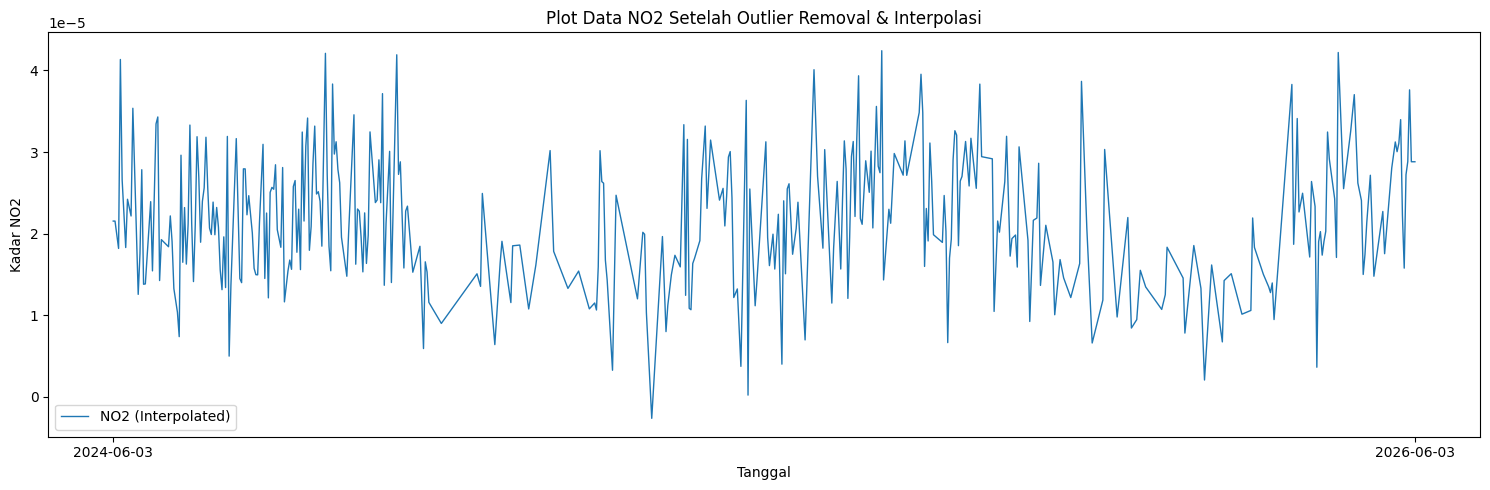

In [51]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

**Keterangan:**

* `plt.figure(figsize=(15,5))` digunakan untuk membuat area grafik dengan ukuran 15 × 5 inci agar visualisasi lebih jelas.
* `plt.plot()` digunakan untuk menampilkan grafik deret waktu (time series) dari data konsentrasi NO₂ setelah proses penghapusan outlier dan interpolasi.
* `plt.xticks()` digunakan untuk mengatur tampilan sumbu X agar hanya menampilkan tanggal awal dan tanggal akhir periode pengamatan sehingga grafik lebih mudah dibaca.
* `plt.title()` digunakan untuk memberikan judul grafik yang menjelaskan isi visualisasi.
* `plt.xlabel()` dan `plt.ylabel()` digunakan untuk memberikan keterangan pada sumbu X dan sumbu Y.
* `plt.legend()` digunakan untuk menampilkan keterangan data yang divisualisasikan.
* `plt.tight_layout()` digunakan untuk menyesuaikan tata letak grafik agar seluruh elemen dapat ditampilkan dengan rapi.
* `plt.show()` digunakan untuk menampilkan grafik hasil visualisasi.

Visualisasi ini bertujuan untuk menampilkan data konsentrasi NO₂ yang telah melalui proses penanganan outlier dan interpolasi. Grafik digunakan untuk memastikan bahwa data telah bersih dari nilai anomali yang mengganggu serta memiliki pola deret waktu yang lebih kontinu dan siap digunakan pada tahap pemodelan prediksi.


# 3. Modeling menggunakan KNN Regression
Dengan data Time Series kadar NO2 harian di daerah Makassar, kita akan memprediksi kadar NO2 satu hari yang akan datang. Sekarang kita akan ubah data, mencoba mencari korelasi antara 1 hari dengan 4 hari sebelumnya. Kita juga akan membandingkan apakah semakin banyak hari sebelumnya, model akan lebih bagus?

In [53]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Baca data
df = pd.read_csv("NO2_Makassar_interpolated.csv")

# Scaling NO2 ke rentang 0-1
scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

print(df.head())

         date       NO2  NO2_scaled
0  2024-06-03  0.000022    0.320379
1  2024-06-04  0.000022    0.320379
2  2024-06-05  0.000020    0.298171
3  2024-06-06  0.000018    0.275963
4  2024-06-07  0.000041    0.582828


**Keterangan:**

* `pd.read_csv("NO2_Makassar_interpolated.csv")` digunakan untuk membaca data NO₂ yang telah melalui proses interpolasi dan siap digunakan untuk pemodelan.
* `MinMaxScaler()` digunakan untuk melakukan normalisasi data dengan mengubah rentang nilai menjadi 0 hingga 1.
* `fit_transform()` digunakan untuk menghitung nilai minimum dan maksimum data sekaligus melakukan proses normalisasi pada kolom NO₂.
* Hasil normalisasi disimpan pada kolom baru bernama `NO2_scaled`.
* `print(df.head())` digunakan untuk menampilkan lima data pertama sebagai verifikasi bahwa proses normalisasi telah berhasil dilakukan.

Tahap normalisasi dilakukan untuk menyamakan skala data sehingga seluruh nilai berada pada rentang 0–1. Proses ini penting karena algoritma K-Nearest Neighbor (KNN) menggunakan perhitungan jarak antar data, sehingga perbedaan skala dapat memengaruhi hasil prediksi. Dengan normalisasi, setiap data memiliki kontribusi yang lebih seimbang dalam proses pembelajaran model.


In [58]:
def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    df_supervised['NO2(t)'] = data

    df_supervised.dropna(inplace=True)

    return df_supervised

supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

lag_cols = supervised_df30.drop(columns="NO2(t)").columns

correlations = supervised_df30[lag_cols].corrwith(
    supervised_df30['NO2(t)']
)

print(correlations)

NO2(t-30)    0.195565
NO2(t-29)    0.181234
NO2(t-28)    0.185235
NO2(t-27)    0.219844
NO2(t-26)    0.244205
NO2(t-25)    0.246834
NO2(t-24)    0.265030
NO2(t-23)    0.243218
NO2(t-22)    0.232840
NO2(t-21)    0.214624
NO2(t-20)    0.200894
NO2(t-19)    0.169063
NO2(t-18)    0.160133
NO2(t-17)    0.197079
NO2(t-16)    0.212636
NO2(t-15)    0.234408
NO2(t-14)    0.254134
NO2(t-13)    0.273569
NO2(t-12)    0.277854
NO2(t-11)    0.295580
NO2(t-10)    0.335621
NO2(t-9)     0.311357
NO2(t-8)     0.328764
NO2(t-7)     0.324916
NO2(t-6)     0.330422
NO2(t-5)     0.329661
NO2(t-4)     0.407752
NO2(t-3)     0.417608
NO2(t-2)     0.512673
NO2(t-1)     0.653955
dtype: float64


**Keterangan:**

* Fungsi `create_supervised()` digunakan untuk mengubah data deret waktu (time series) menjadi format *supervised learning* yang dapat digunakan oleh algoritma machine learning.
* Parameter `n_lag=30` menunjukkan bahwa model menggunakan 30 data hari sebelumnya sebagai fitur untuk memprediksi nilai NO₂ pada hari berikutnya.
* `data.shift(i)` digunakan untuk menggeser data sehingga terbentuk fitur lag, yaitu nilai NO₂ pada waktu sebelumnya (`t-30` hingga `t-1`).
* Kolom `NO2(t)` berisi nilai target yang akan diprediksi oleh model.
* `dropna()` digunakan untuk menghapus baris yang mengandung nilai kosong akibat proses pergeseran (shift).
* `supervised_df30` merupakan dataset hasil transformasi yang terdiri dari 30 fitur lag dan 1 variabel target.
* `corrwith()` digunakan untuk menghitung nilai korelasi antara setiap fitur lag dengan variabel target `NO2(t)`.
* `print(correlations)` digunakan untuk menampilkan hasil korelasi masing-masing lag terhadap nilai NO₂ saat ini.

Tahap ini bertujuan untuk mengubah data time series menjadi bentuk supervised learning sehingga dapat digunakan pada proses pemodelan K-Nearest Neighbor (KNN) Regression. Selain itu, analisis korelasi dilakukan untuk mengetahui seberapa kuat hubungan antara nilai NO₂ pada hari-hari sebelumnya dengan nilai NO₂ yang akan diprediksi.


## b. Normalisasi Data
karena kita menggunakan model KNN Regression, maka perlu normalisasi data menggunakan min-max Scaler.

In [56]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

# Menampilkan 5 data pertama
print(df.head())

# Menampilkan informasi dataframe
print()
df.info()

         date       NO2  NO2_scaled
0  2024-06-03  0.000022    0.320379
1  2024-06-04  0.000022    0.320379
2  2024-06-05  0.000020    0.298171
3  2024-06-06  0.000018    0.275963
4  2024-06-07  0.000041    0.582828

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        731 non-null    object 
 1   NO2         731 non-null    float64
 2   NO2_scaled  731 non-null    float64
dtypes: float64(2), object(1)
memory usage: 17.3+ KB


**Keterangan:**

* `MinMaxScaler()` digunakan untuk melakukan normalisasi data dengan mengubah rentang nilai menjadi 0 hingga 1.
* `fit_transform(df[['NO2']])` digunakan untuk menghitung nilai minimum dan maksimum pada data NO₂, kemudian melakukan proses normalisasi terhadap seluruh data.
* Hasil normalisasi disimpan pada kolom baru bernama `NO2_scaled`.
* `print(df.head())` digunakan untuk menampilkan lima data pertama sehingga dapat dilihat perbandingan antara nilai NO₂ asli dan nilai yang telah dinormalisasi.
* `df.info()` digunakan untuk menampilkan informasi struktur dataset, seperti jumlah baris, jumlah kolom, tipe data setiap kolom, serta jumlah data yang tidak kosong (*non-null*).

Tahap ini bertujuan untuk melakukan normalisasi data sebelum proses pemodelan. Normalisasi diperlukan karena algoritma K-Nearest Neighbor (KNN) menghitung jarak antar data, sehingga seluruh fitur perlu berada pada skala yang sama agar tidak ada nilai yang mendominasi proses perhitungan jarak. Selain itu, pemeriksaan menggunakan `head()` dan `info()` dilakukan untuk memastikan bahwa proses normalisasi berhasil dan tidak mengubah struktur data.


## c. Mengubah Data
Sekarang saya ingin mengubah data dari sebelumnya hanya 2 fitru menjadi 4 hari sebelum yang terdapat 5 fitur (t-4, t-3, t-2, t-1, dan t sebagai label) karena dari uji korelasi, keempat fitur tersebut (t-1 sampai t-4) merupakan nilai uji korelasi terbaik (lebih dari 0.5). Saya juga membuat data 10 hari sebelum untuk membandingkan apakah semakin banyak hari sebelum, semakin baik pula modelnya?

In [57]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.320379  0.320379  0.298171  0.275963  0.582828
5    0.320379  0.298171  0.275963  0.582828  0.387003
6    0.298171  0.275963  0.582828  0.387003  0.332219
7    0.275963  0.582828  0.387003  0.332219  0.277435
8    0.582828  0.387003  0.332219  0.277435  0.355819
..        ...       ...       ...       ...       ...
726  0.485156  0.329620  0.243947  0.395709  0.417040
727  0.329620  0.243947  0.395709  0.417040  0.533513
728  0.243947  0.395709  0.417040  0.533513  0.416733
729  0.395709  0.417040  0.533513  0.416733  0.866729
730  0.417040  0.533513  0.416733  0.866729  0.866729

[727 rows x 5 columns]
(727, 5)


**Keterangan:**

* `create_supervised(df['NO2_scaled'], n_lag=4)` digunakan untuk mengubah data time series NO₂ menjadi format *supervised learning* dengan menggunakan 4 data sebelumnya sebagai fitur prediksi.
* Kolom `NO2(t-4)`, `NO2(t-3)`, `NO2(t-2)`, dan `NO2(t-1)` berisi nilai NO₂ pada empat hari sebelumnya, sedangkan kolom `NO2(t)` berisi nilai target yang akan diprediksi.
* `supervised_df` digunakan untuk menyimpan hasil transformasi data time series ke dalam bentuk tabel yang dapat digunakan oleh algoritma machine learning.
* `print(supervised_df)` digunakan untuk menampilkan isi dataset hasil transformasi sehingga dapat dilihat struktur fitur dan target yang terbentuk.
* `print(supervised_df.shape)` digunakan untuk menampilkan ukuran dataset dalam bentuk `(jumlah_baris, jumlah_kolom)`.

Tahap ini bertujuan untuk mengubah data deret waktu menjadi format supervised learning yang dapat diproses oleh algoritma K-Nearest Neighbor (KNN) Regression. Dengan menggunakan 4 nilai NO₂ sebelumnya sebagai fitur, model dapat mempelajari pola historis data untuk memprediksi nilai NO₂ pada waktu berikutnya.


In [59]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.320379  0.320379  0.298171  0.275963  0.582828  0.387003  0.332219   
11    0.320379  0.298171  0.275963  0.582828  0.387003  0.332219  0.277435   
12    0.298171  0.275963  0.582828  0.387003  0.332219  0.277435  0.355819   
13    0.275963  0.582828  0.387003  0.332219  0.277435  0.355819  0.342233   
14    0.582828  0.387003  0.332219  0.277435  0.355819  0.342233  0.328646   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.371710  0.406478  0.427682  0.448885  0.433073  0.446938  0.485156   
727   0.406478  0.427682  0.448885  0.433073  0.446938  0.485156  0.329620   
728   0.427682  0.448885  0.433073  0.446938  0.485156  0.329620  0.243947   
729   0.448885  0.433073  0.446938  0.485156  0.329620  0.243947  0.395709   
730   0.433073  0.446938  0.485156  0.329620  0.243947  0.395709  0.417040   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.277435  0.

**Keterangan:**

* `create_supervised(df['NO2_scaled'], n_lag=10)` digunakan untuk mengubah data time series NO₂ menjadi format *supervised learning* dengan memanfaatkan 10 data sebelumnya sebagai fitur prediksi.
* Kolom `NO2(t-10)` hingga `NO2(t-1)` berisi nilai konsentrasi NO₂ pada 10 hari sebelumnya, sedangkan kolom `NO2(t)` merupakan nilai target yang akan diprediksi.
* `supervised_df10` digunakan untuk menyimpan hasil transformasi data dengan 10 lag sehingga model memiliki lebih banyak informasi historis dibandingkan penggunaan 4 lag.
* `print(supervised_df10)` digunakan untuk menampilkan isi dataset hasil transformasi agar dapat dilihat struktur fitur dan target yang terbentuk.
* `print(supervised_df10.shape)` digunakan untuk menampilkan ukuran dataset dalam bentuk `(jumlah_baris, jumlah_kolom)`.

Tahap ini bertujuan untuk membentuk dataset supervised learning menggunakan 10 hari pengamatan sebelumnya sebagai variabel input. Penambahan jumlah lag dilakukan untuk melihat apakah informasi historis yang lebih panjang dapat membantu model K-Nearest Neighbor (KNN) Regression dalam memprediksi konsentrasi NO₂ dengan lebih baik.


## d. Modeling dan Evaluation
Sekarang dari 2 data yang sudah kita rubah, kita train menggunakan model KNN Regression.

In [60]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.088995
R² Score: 0.5321
MAPE: 19.4931%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.096416
R² Score: 0.4516
MAPE: 22.2835%


**Keterangan:**

* Fungsi `MAPE()` digunakan untuk menghitung *Mean Absolute Percentage Error* (MAPE), yaitu persentase rata-rata kesalahan prediksi model terhadap nilai sebenarnya.
* Fungsi `train_knn()` digunakan untuk melatih dan mengevaluasi model K-Nearest Neighbor (KNN) Regression.
* `X` berisi fitur (data lag sebelumnya), sedangkan `y` berisi target yang akan diprediksi (`NO2(t)`).
* `train_test_split()` digunakan untuk membagi data menjadi data latih (*training*) sebesar 80% dan data uji (*testing*) sebesar 20%. Parameter `shuffle=False` digunakan agar urutan waktu pada data time series tetap terjaga.
* `KNeighborsRegressor(n_neighbors=5)` digunakan untuk membangun model KNN dengan 5 tetangga terdekat (*k = 5*).
* `fit()` digunakan untuk melatih model menggunakan data latih.
* `predict()` digunakan untuk menghasilkan prediksi pada data uji.
* `mean_squared_error()`, `r2_score()`, dan `MAPE()` digunakan untuk mengevaluasi performa model.
* RMSE (*Root Mean Square Error*) menunjukkan besar rata-rata kesalahan prediksi, semakin kecil nilainya maka model semakin baik.
* R² Score menunjukkan kemampuan model dalam menjelaskan variasi data, dengan nilai mendekati 1 menunjukkan performa yang lebih baik.
* MAPE menunjukkan persentase kesalahan prediksi, semakin kecil nilainya maka hasil prediksi semakin akurat.
* Model dilatih menggunakan dua skenario, yaitu 4 hari sebelumnya (`supervised_df`) dan 10 hari sebelumnya (`supervised_df10`) untuk membandingkan pengaruh jumlah lag terhadap performa prediksi.

Tahap ini merupakan proses pemodelan menggunakan algoritma K-Nearest Neighbor (KNN) Regression. Model dilatih menggunakan data historis NO₂ dan kemudian dievaluasi menggunakan metrik RMSE, R² Score, dan MAPE. Hasil evaluasi digunakan untuk menentukan konfigurasi lag yang memberikan performa prediksi terbaik terhadap konsentrasi NO₂ di wilayah Makassar.


In [61]:
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")


=== KNN - 30 Hari Sebelumnya ===
Train Size: 560 — Test Size: 141
RMSE: 0.099179
R² Score: 0.4212
MAPE: 24.2156%


## e. Plotting
Plotting untuk visualisasi grafik antara label dan prediksi dari kedua data diatas.

4 hari sebelum:

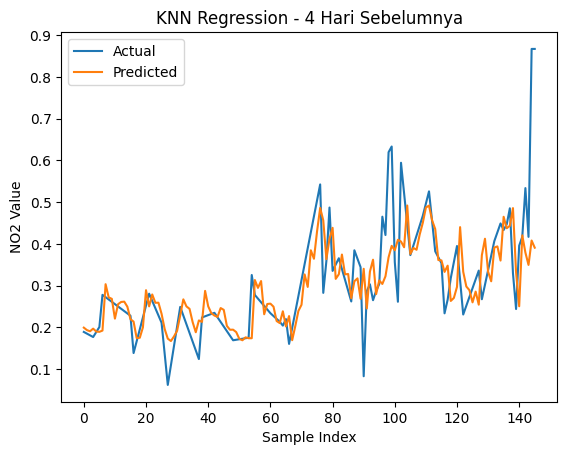

In [62]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

10 hari sebelum:

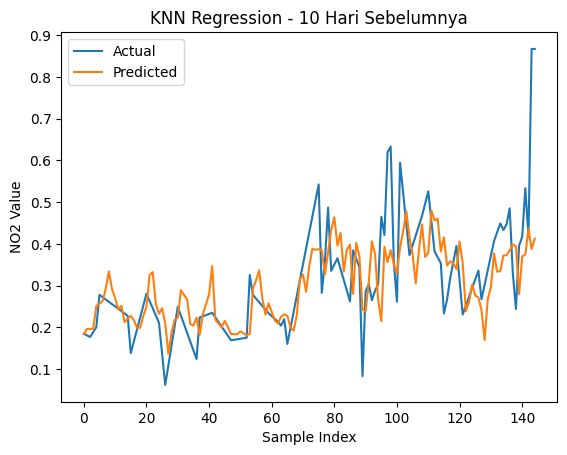

In [63]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

30 hari sebelum:

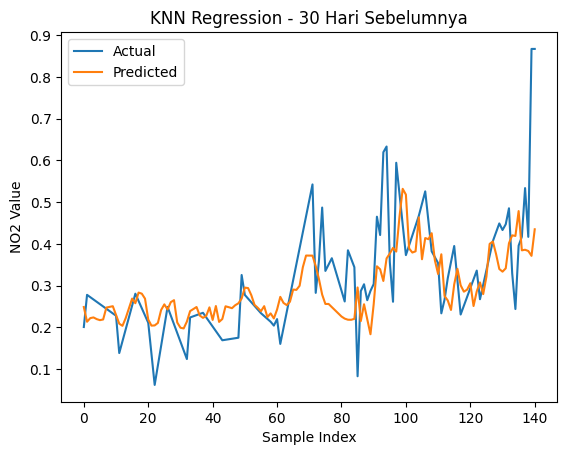

In [64]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()